# FTIR Data analysis

#### libraries

In [10]:
import glob
import os
import pandas as pd
import numpy as np
from specdal import Spectrum
import matplotlib.pyplot as plt
import math
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

In [11]:
# Path to the VNIR-SWIR data folder
data_folder = 'VNIR_SWIR_LG_2024/VNIR_SWIR_LG2_024/'

# Collect all .asd files
files = sorted(glob.glob(os.path.join(data_folder, '*.asd')))

# Initialize an empty list to hold DataFrames
dfs = []

# Loop over all files
for f in files:
    try:
        # Load the spectrum
        spec = Spectrum(filepath=f)
        # Get the filename without extension for column name
        name = os.path.basename(f).replace('.asd', '')
        # Create a DataFrame from the measurement (wavelengths as index, reflectance as column)
        df = spec.measurement.to_frame(name=name)
        dfs.append(df)
    except Exception as e:
        print(f"Error loading {f}: {e}")

# Combine all DataFrames into one, aligned by wavelength index
if dfs:
    alldata = pd.concat(dfs, axis=1)
    # Compute average reflectance
    alldata['Avg refl'] = alldata.mean(axis=1)
    print("Data loaded successfully. Shape:", alldata.shape)
    print(alldata.head())
else:
    print("No valid files loaded.")



Data loaded successfully. Shape: (2151, 1601)
            LA24_0100000  LA24_0100001  LA24_0100002  LA24_0100003  \
wavelength                                                           
350.0           0.058464      0.054332      0.064475      0.055510   
351.0           0.060425      0.054075      0.067319      0.053822   
352.0           0.060410      0.055407      0.063300      0.053993   
353.0           0.057558      0.055819      0.057613      0.056992   
354.0           0.055485      0.050535      0.059566      0.055145   

            LA24_0100004  LA24_0100005  LA24_0100006  LA24_0100007  \
wavelength                                                           
350.0           0.049397      0.060200      0.051914      0.057938   
351.0           0.055180      0.060270      0.060017      0.057703   
352.0           0.057823      0.060900      0.064884      0.056640   
353.0           0.053747      0.061435      0.061061      0.059789   
354.0           0.055575      0.054648     

C:\Users\fionn\AppData\Local\Temp\ipykernel_16044\1330980950.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  alldata['Avg refl'] = alldata.mean(axis=1)


### Test cell

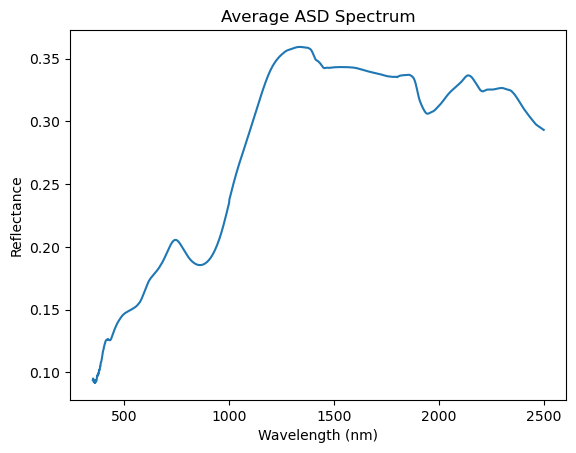

In [12]:
# Example plot of average spectrum
plt.plot(alldata.index, alldata['Avg refl'])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Average ASD Spectrum")
plt.show()

### cluster data sets ; plus hirarchy diagram

In [13]:
# Prepare data for clustering
spectrum_data = alldata.drop('Avg refl', axis=1)

# Compute pairwise distances
from scipy.spatial.distance import pdist
distances = pdist(spectrum_data.T, metric='euclidean')

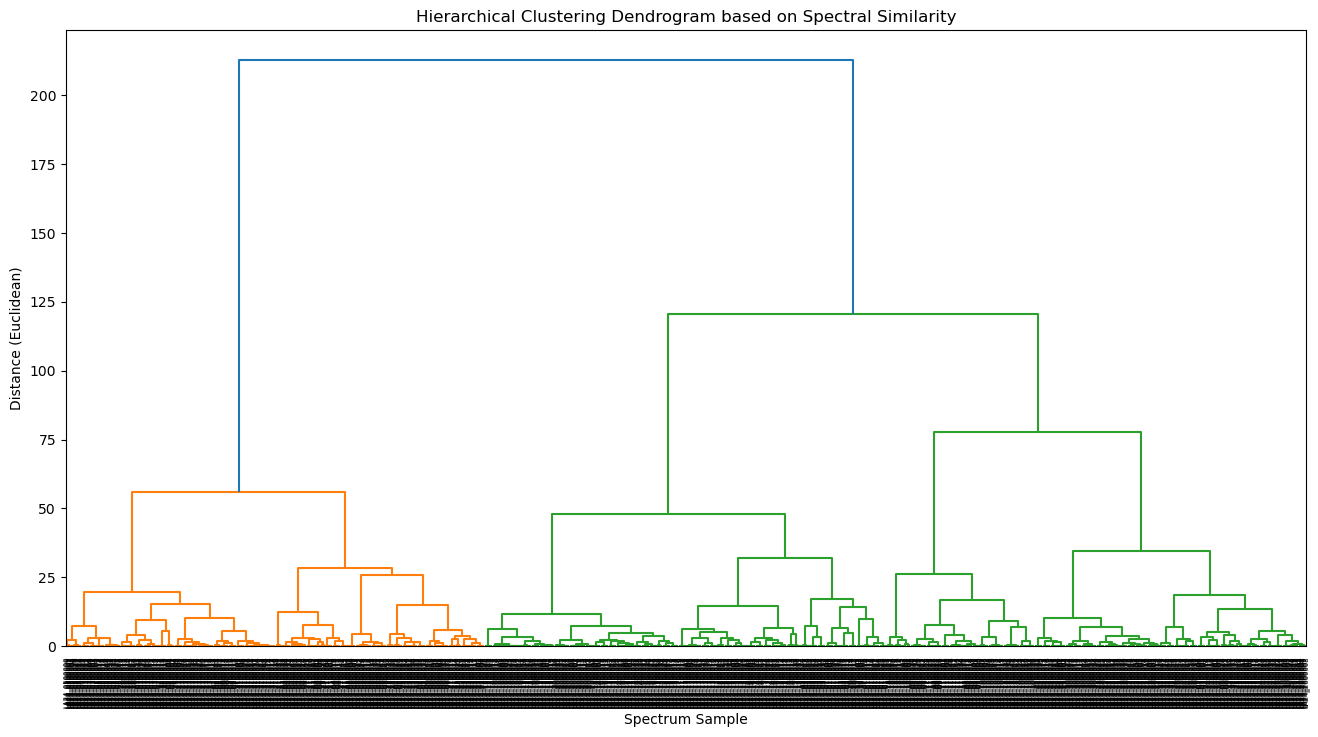

In [19]:
# Perform hierarchical clustering
linkage_matrix = linkage(distances, method='ward')

# Plot dendrogram to visualize clustering
plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix, labels=spectrum_data.columns.astype(str), leaf_rotation=90)
plt.xlabel('Spectrum Sample')
plt.ylabel('Distance (Euclidean)')
plt.title('Hierarchical Clustering Dendrogram based on Spectral Similarity')
#plt.legend(loc='upper right',bbox_to_anchor=(1.15, 1))

plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# Determine optimal number of clusters (using a distance threshold)
# Cut at a certain height to form clusters
num_clusters = int(1600/100)  # Adjust this to change granularity
cluster_labels = fcluster(linkage_matrix, num_clusters, criterion='maxclust')

# Create a mapping of sample to cluster
cluster_assignment = pd.DataFrame({
    'Sample': spectrum_data.columns,
    'Cluster': cluster_labels
})

print("Cluster Assignment:")
print(cluster_assignment)
print(f"\nNumber of clusters: {num_clusters}")
for i in range(1, num_clusters + 1):
    members = cluster_assignment[cluster_assignment['Cluster'] == i]['Sample'].tolist()
    print(f"Cluster {i}: {len(members)} samples - {members[:5]}{'...' if len(members) > 5 else ''}")

Cluster Assignment:
            Sample  Cluster
0     LA24_0100000       10
1     LA24_0100001       10
2     LA24_0100002       10
3     LA24_0100003       10
4     LA24_0100004       10
...            ...      ...
1595  LA24_3200045       15
1596  LA24_3200046       15
1597  LA24_3200047       15
1598  LA24_3200048       15
1599  LA24_3200049       15

[1600 rows x 2 columns]

Number of clusters: 16
Cluster 1: 70 samples - ['LA24_0500000', 'LA24_0500001', 'LA24_0500002', 'LA24_0500003', 'LA24_0500004']...
Cluster 2: 70 samples - ['LA24_0200000', 'LA24_0200001', 'LA24_0200002', 'LA24_0200003', 'LA24_0200004']...
Cluster 3: 130 samples - ['LA24_0200010', 'LA24_0200011', 'LA24_0200012', 'LA24_0200013', 'LA24_0200014']...
Cluster 4: 94 samples - ['LA24_0400000', 'LA24_0400001', 'LA24_0400002', 'LA24_0400003', 'LA24_0400004']...
Cluster 5: 50 samples - ['LA24_0800000', 'LA24_0800001', 'LA24_0800002', 'LA24_0800003', 'LA24_0800004']...
Cluster 6: 126 samples - ['LA24_0200020', 'LA24_020002

C:\Users\fionn\AppData\Local\Temp\ipykernel_16044\204329611.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))


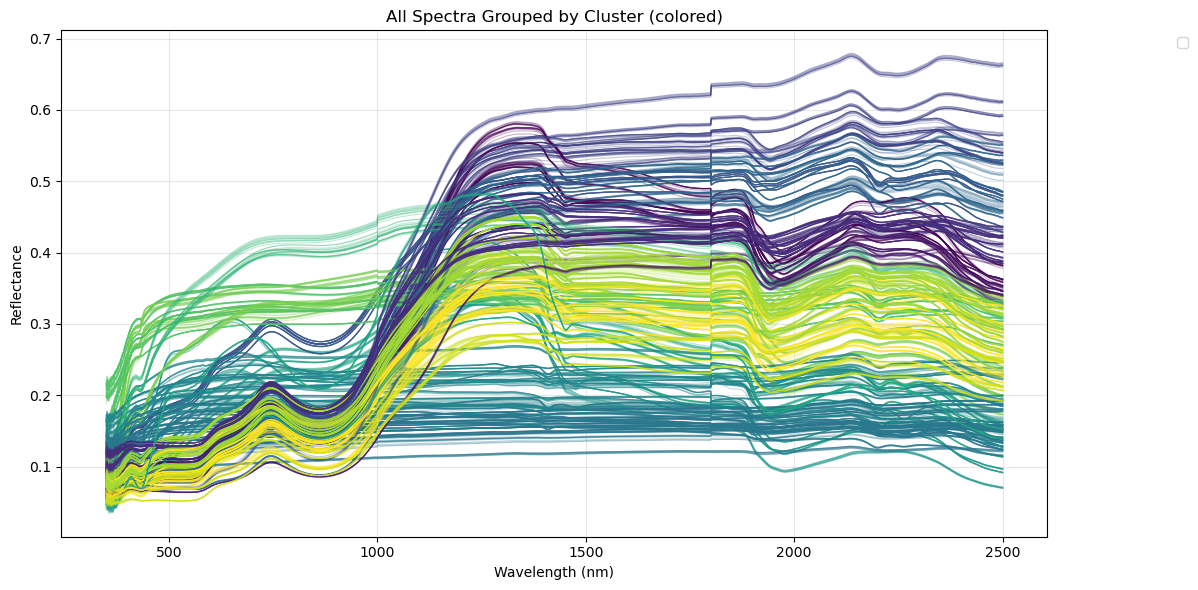

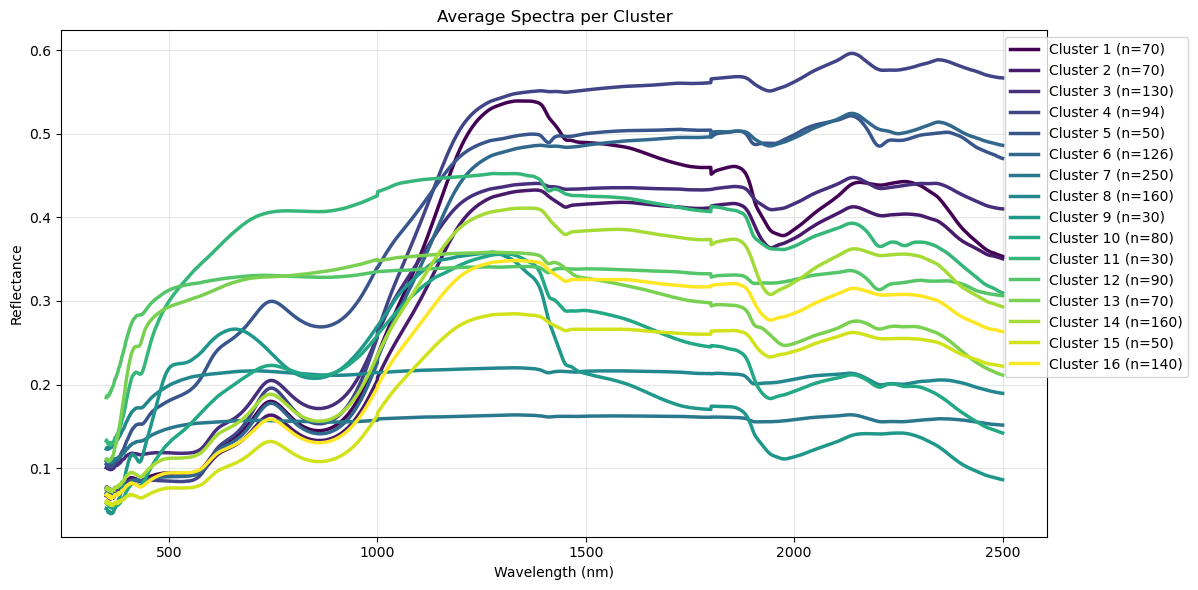

In [21]:
# Create subplots: one for all spectra colored by cluster, one for cluster averages
# Define colors for clusters
colors = plt.cm.viridis(np.linspace(0, 1, num_clusters))


# All spectra colored by cluster
plt.figure(figsize=(12, 6))  # Full-sized figure

for idx, sample in enumerate(spectrum_data.columns):
    cluster_id = cluster_assignment[cluster_assignment['Sample'] == sample]['Cluster'].values[0]
    color = colors[cluster_id - 1]
    plt.plot(spectrum_data.index, spectrum_data[sample], alpha=0.3, color=color, linewidth=0.8)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')
plt.title('All Spectra Grouped by Cluster (colored)')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('all_spectra_no_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

#cluster average
plt.figure(figsize=(12, 6))  # Full-sized figure

cluster_averages = {}
for cluster_id in range(1, num_clusters + 1):
    members = cluster_assignment[cluster_assignment['Cluster'] == cluster_id]['Sample'].tolist()
    cluster_data = spectrum_data[members]
    cluster_avg = cluster_data.mean(axis=1)
    cluster_averages[cluster_id] = cluster_avg

    color = colors[cluster_id - 1]
    plt.plot(spectrum_data.index, cluster_avg, label=f'Cluster {cluster_id} (n={len(members)})',
             linewidth=2.5, color=color)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')
plt.title('Average Spectra per Cluster')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_averages.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
print("\nCluster Summary:")
for cluster_id in range(1, num_clusters + 1):
    members = cluster_assignment[cluster_assignment['Cluster'] == cluster_id]['Sample'].tolist()
    print(f"Cluster {cluster_id}: {len(members)} samples")


Cluster Summary:
Cluster 1: 70 samples
Cluster 2: 70 samples
Cluster 3: 130 samples
Cluster 4: 94 samples
Cluster 5: 50 samples
Cluster 6: 126 samples
Cluster 7: 250 samples
Cluster 8: 160 samples
Cluster 9: 30 samples
Cluster 10: 80 samples
Cluster 11: 30 samples
Cluster 12: 90 samples
Cluster 13: 70 samples
Cluster 14: 160 samples
Cluster 15: 50 samples
Cluster 16: 140 samples


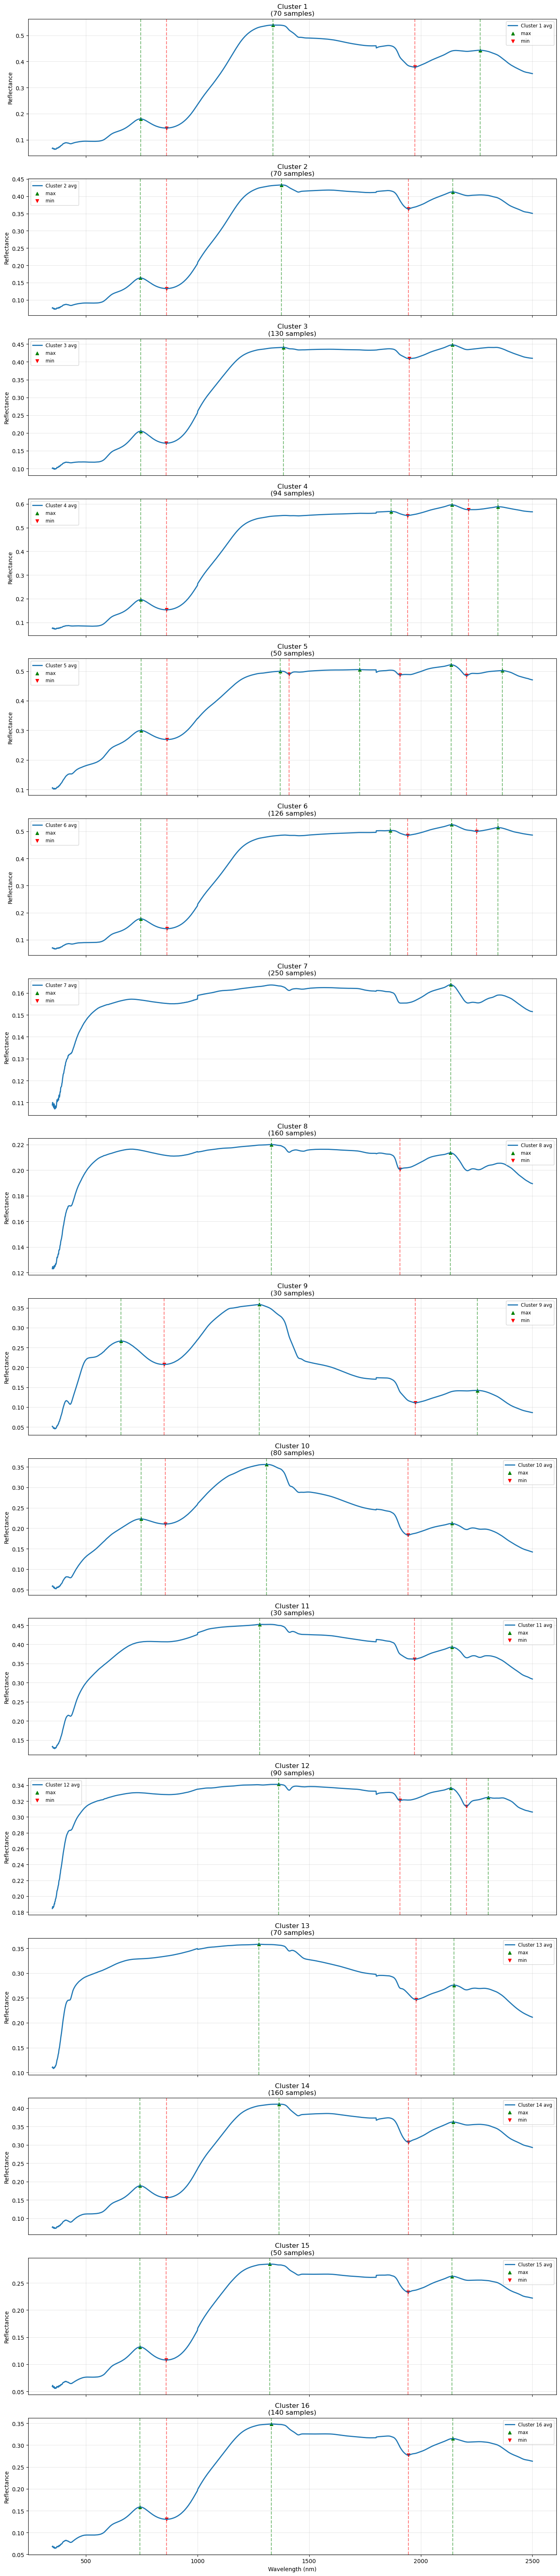


Cluster 1 extrema (count max=3, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      745.0     0.179833
     1338.0     0.539211
     2267.0     0.442779
Minima (wavelength, reflectance):
 Wavelength  Reflectance
      862.0     0.144803
     1973.0     0.378146

Cluster 2 extrema (count max=3, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      744.0     0.163442
     1376.0     0.432673
     2143.0     0.412561
Minima (wavelength, reflectance):
 Wavelength  Reflectance
      862.0     0.132980
     1945.0     0.363478

Cluster 3 extrema (count max=3, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      746.0     0.204897
     1385.0     0.440549
     2141.0     0.447648
Minima (wavelength, reflectance):
 Wavelength  Reflectance
      860.0     0.171322
     1948.0     0.409190

Cluster 4 extrema (count max=4, min=3)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      746.0     0.195736
     1867.0     0.568268
  

In [24]:
# Verify cluster data exists
if 'cluster_averages' not in globals() or not cluster_averages:
    raise ValueError('cluster_averages is missing. Run clustering code first.')

cluster_ids = sorted(cluster_averages.keys())
fig, axs = plt.subplots(len(cluster_ids), 1, figsize=(14, 4 * len(cluster_ids)), sharex=True)
if len(cluster_ids) == 1:
    axs = [axs]

for i, cluster_id in enumerate(cluster_ids):
    cluster_avg = cluster_averages[cluster_id]
    ax = axs[i]

    # Detect local extrema on the average spectrum with filtering
    maxima_idx, _ = find_peaks(cluster_avg.values, distance=20, prominence=0.01)
    minima_idx, _ = find_peaks(-cluster_avg.values, distance=20, prominence=0.01)

    # Plot average curve
    ax.plot(cluster_avg.index, cluster_avg.values, color='tab:blue', linewidth=2, label=f'Cluster {cluster_id} avg')

    # Vertical lines: maxima / minima
    for idx in maxima_idx:
        ax.axvline(cluster_avg.index[idx], color='green', linestyle='--', alpha=0.5)
    for idx in minima_idx:
        ax.axvline(cluster_avg.index[idx], color='red', linestyle='--', alpha=0.5)

    # Mark the points
    ax.scatter(cluster_avg.index[maxima_idx], cluster_avg.values[maxima_idx], color='green', s=30, marker='^', label='max')
    ax.scatter(cluster_avg.index[minima_idx], cluster_avg.values[minima_idx], color='red', s=30, marker='v', label='min')

    ax.set_title(f'Cluster {cluster_id}\n({len(cluster_assignment[cluster_assignment.Cluster==cluster_id])} samples)')
    ax.set_ylabel('Reflectance')
    ax.legend(loc='best', fontsize='small')
    ax.grid(True, alpha=0.3)

axs[-1].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.savefig('cluster_extrema.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional summary table of extrema for each cluster
for cluster_id in cluster_ids:
    cluster_avg = cluster_averages[cluster_id]
    maxima_idx, _ = find_peaks(cluster_avg.values, distance=20, prominence=0.01)
    minima_idx, _ = find_peaks(-cluster_avg.values, distance=20, prominence=0.01)

    max_points = list(zip(cluster_avg.index[maxima_idx], cluster_avg.values[maxima_idx]))
    min_points = list(zip(cluster_avg.index[minima_idx], cluster_avg.values[minima_idx]))

    print(f"\nCluster {cluster_id} extrema (count max={len(max_points)}, min={len(min_points)})")
    print("Maxima (wavelength, reflectance):")
    print(pd.DataFrame(max_points, columns=['Wavelength', 'Reflectance']).head(10).to_string(index=False))
    print("Minima (wavelength, reflectance):")
    print(pd.DataFrame(min_points, columns=['Wavelength', 'Reflectance']).head(10).to_string(index=False))